# Capítulo 1 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Este notebook resolve os exercícios teóricos **T1–T5** (com `sympy` onde a álgebra ajuda) e os numéricos **N1–N4** do notebook `cap01_fundamentos.ipynb`. Não distribuir aos alunos antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

Rd, g = 287.0, 9.8
a  = Rd/g
P0 = 101.325  # kPa

## T1 — Atmosfera isotérmica: $H_p = H_\rho$

**Enunciado.** Mostre que numa atmosfera isotérmica as escalas de altura de pressão e densidade coincidem, $H_p = H_\rho = \Re_d T/g$, e calcule-as para $T = 250$ K.

**Solução.** Da hidrostática + gás ideal, $dP/P = -\,g/(\Re_d T)\,dz$. Com $T$ constante, integra para $P = P_0 e^{-z/H}$ com $H = \Re_d T/g$. A densidade é $\rho = P/(\Re_d T)$: com $T$ constante, $\rho \propto P$, logo $\rho = \rho_0 e^{-z/H}$ com o **mesmo** $H$. Na atmosfera real $T$ cai com $z$ na troposfera, o que faz $\rho$ cair mais devagar que $P$ ($H_\rho = 8{,}55 > H_p = 7{,}29$ km).

In [2]:
# verificação simbólica: resolver a EDO e comparar P/P0 com rho/rho0
z_, T_, Rd_, g_, P0_ = sp.symbols('z T R_d g P_0', positive=True)
P_ = sp.Function('P', positive=True)
sol = sp.dsolve(sp.Eq(P_(z_).diff(z_), -g_*P_(z_)/(Rd_*T_)), P_(z_),
                ics={P_(0): P0_})
display(sol)
rho_sobre_rho0 = sp.simplify((sol.rhs/(Rd_*T_)) / (P0_/(Rd_*T_)))
print('rho/rho0 =', rho_sobre_rho0, ' → mesma exponencial, logo H_p = H_rho.')
print(f'Para T = 250 K:  H = Rd*T/g = {Rd*250/g/1e3:.2f} km')

Eq(P(z), P_0*exp(-g*z/(R_d*T)))

rho/rho0 = exp(-g*z/(R_d*T))  → mesma exponencial, logo H_p = H_rho.
Para T = 250 K:  H = Rd*T/g = 7.32 km


## T2 — Perfil politrópico de pressão

**Enunciado.** Para $T(z) = T_0 - \gamma z$, deduza
$$P(z) = P_0\left(1 - \frac{\gamma z}{T_0}\right)^{g/(\Re_d \gamma)}$$
e mostre que no limite $\gamma \to 0$ recupera-se a exponencial isotérmica.

**Solução.** Separando variáveis:
$$\int_{P_0}^{P}\frac{dP'}{P'} = -\frac{g}{\Re_d}\int_0^z\frac{dz'}{T_0-\gamma z'}
\;\Rightarrow\; \ln\frac{P}{P_0} = \frac{g}{\Re_d\gamma}\ln\!\Big(1-\frac{\gamma z}{T_0}\Big),$$
que exponenciada dá o resultado. Para $\gamma\to0$, use $(1-x)^{1/x}\to e^{-1}$: o expoente $g/(\Re_d\gamma)$ vezes $\ln(1-\gamma z/T_0)\approx-\gamma z/T_0$ dá $-gz/(\Re_d T_0)$, ou seja $P\to P_0e^{-z/H}$. ∎

In [3]:
# verificação simbólica da dedução e do limite
gam = sp.symbols('gamma', positive=True)
T0_ = sp.symbols('T_0', positive=True)
sol2 = sp.dsolve(sp.Eq(P_(z_).diff(z_), -g_*P_(z_)/(Rd_*(T0_-gam*z_))), P_(z_),
                 ics={P_(0): P0_})
P_poli = sp.simplify(sol2.rhs)
display(sp.Eq(sp.Symbol('P'), P_poli))
limite = sp.simplify(sp.limit(P_poli, gam, 0))
display(sp.Eq(sp.Symbol('P_iso'), limite))
print('Limite gamma→0 recupera a exponencial isotérmica ✓')

Eq(P, P_0*exp(g*(-log(T_0) + log(-T_0 + gamma*z) - I*pi)/(R_d*gamma)))

Eq(P_iso, P_0*exp(-g*z/(R_d*T_0)))

Limite gamma→0 recupera a exponencial isotérmica ✓


## T3 — Dedução da temperatura virtual

**Enunciado.** A partir da lei de Dalton para uma mistura de ar seco (pressão parcial $P_d$) e vapor (pressão $e$), com $\varepsilon = M_v/M_d = 0{,}622$, deduza $T_v \simeq T(1+0{,}61\,r)$.

**Solução.** A densidade da mistura é
$$\rho = \rho_d + \rho_v = \frac{P-e}{\Re_d T} + \frac{e}{\Re_v T}
 = \frac{P}{\Re_d T}\Big[1 - \frac{e}{P}(1-\varepsilon)\Big].$$
Definindo $T_v$ por $\rho \equiv P/(\Re_d T_v)$:
$$T_v = \frac{T}{1-\tfrac{e}{P}(1-\varepsilon)}.$$
Com $r = \varepsilon e/(P-e)$ ⇒ $e/P = r/(\varepsilon + r)$; expandindo em 1ª ordem em $r$:
$$T_v \simeq T\Big[1 + \Big(\tfrac{1-\varepsilon}{\varepsilon}\Big) r\Big] = T(1+0{,}608\,r)\approx T(1+0{,}61\,r).\;∎$$

In [4]:
# verificação simbólica da expansão
r_, eps = sp.symbols('r varepsilon', positive=True)
e_sobre_P = r_/(eps + r_)
Tv_exato = 1/(1 - e_sobre_P*(1-eps))          # Tv/T exato
serie = sp.series(Tv_exato, r_, 0, 2).removeO()
display(sp.Eq(sp.Symbol('T_v/T'), sp.simplify(serie)))
coef = sp.simplify((serie - 1)/r_).subs(eps, sp.Rational(622, 1000))
print(f'coeficiente = (1-ε)/ε = {float(coef):.4f}  (livro: 0,61) ✓')

Eq(T_v/T, -r + r/varepsilon + 1)

coeficiente = (1-ε)/ε = 0.6077  (livro: 0,61) ✓


## T4 — Massa da atmosfera

**Enunciado.** Mostre que a massa de ar por unidade de área acima da superfície é $m = P_0/g$, e estime a massa total da atmosfera terrestre.

**Solução.** Integrando a hidrostática de 0 a ∞: $P_0 - 0 = \int_0^\infty \rho g\,dz = g\,m$, logo $m = P_0/g$. Cada m² de chão sustenta ~10,3 toneladas de ar. Multiplicando pela área da Terra $4\pi R_T^2$:

In [5]:
m_col = P0*1e3/g                      # kg/m²
R_T = 6.371e6
M_atm = m_col * 4*np.pi*R_T**2
print(f'massa por m²: {m_col:,.0f} kg/m²  (~10,3 t)')
print(f'massa total da atmosfera: {M_atm:.2e} kg  (literatura: ~5,1×10^18 kg) ✓')

massa por m²: 10,339 kg/m²  (~10,3 t)
massa total da atmosfera: 5.27e+18 kg  (literatura: ~5,1×10^18 kg) ✓


## T5 — A regra dos 5400 m

**Enunciado.** Mostre que a espessura 1000–500 hPa vale $\Delta z = a\bar T_v\ln 2$ e determine que $\bar T_v$ corresponde ao limiar operacional de 5400 m. Por que faz sentido físico esse limiar separar chuva de neve?

**Solução.** Com $P_1/P_2 = 2$, $\Delta z = a\bar T_v\ln 2 = 20{,}3\;\mathrm{m/K}\times\bar T_v$. Para $\Delta z = 5400$ m: $\bar T_v = 5400/(29{,}3\times0{,}693) = 266$ K $= -7{,}2$ °C. Uma camada 1000–500 com média de −7 °C tipicamente tem a metade inferior perto de 0 °C — flocos que caem não derretem no caminho. Camada mais espessa ⇒ coluna mais quente ⇒ neve derrete antes do chão.

In [6]:
Tv_5400 = 5400/(a*np.log(2))
print(f'a·ln2 = {a*np.log(2):.1f} m/K;   Tv(5400 m) = {Tv_5400:.1f} K = {Tv_5400-273.15:.1f} °C')

a·ln2 = 20.3 m/K;   Tv(5400 m) = 266.0 K = -7.1 °C


---
## N1 — Troposfera politrópica: numérico × analítico

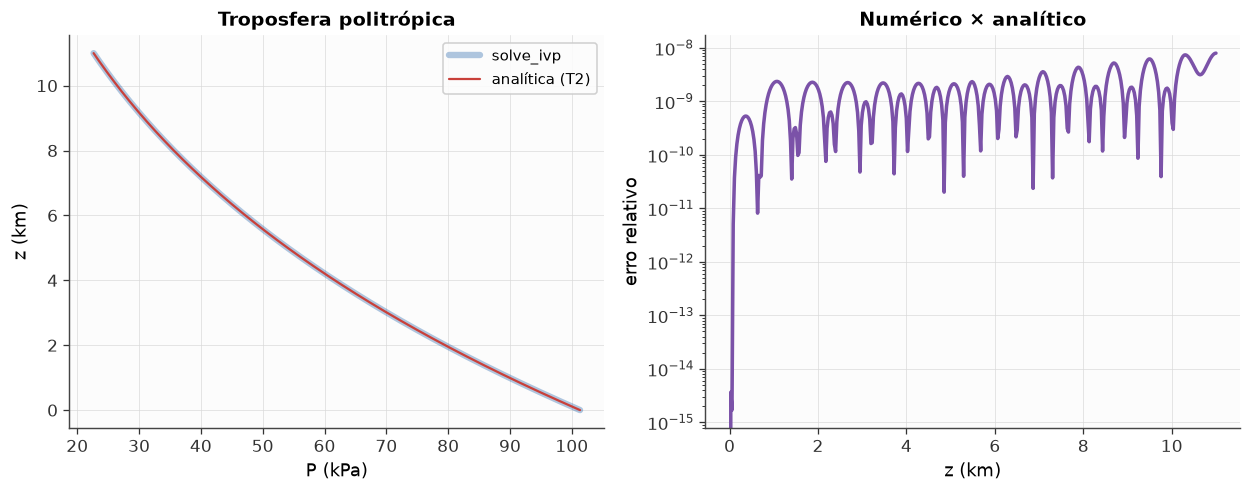

erro relativo máximo: 7.95e-09 — o integrador reproduz a solução exata.


In [7]:
from scipy.integrate import solve_ivp

T0, gam = 288.15, 6.5e-3          # K, K/m
z = np.linspace(0, 11e3, 400)

sol = solve_ivp(lambda zz, P: -g*P/(Rd*(T0-gam*zz)), [0, 11e3], [P0],
                dense_output=True, rtol=1e-10)
P_num  = sol.sol(z)[0]
P_ana  = P0*(1 - gam*z/T0)**(g/(Rd*gam))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
ax1.plot(P_num, z/1e3, color=CORES['azul'], lw=4, alpha=0.35, label='solve_ivp')
ax1.plot(P_ana, z/1e3, color=CORES['vermelho'], lw=1.4, label='analítica (T2)')
ax1.set(xlabel='P (kPa)', ylabel='z (km)', title='Troposfera politrópica')
ax1.legend()
ax2.semilogy(z/1e3, np.abs(P_num-P_ana)/P_ana, color=CORES['roxo'])
ax2.set(xlabel='z (km)', ylabel='erro relativo', title='Numérico × analítico')
fig.tight_layout(); plt.show()
print(f'erro relativo máximo: {np.max(np.abs(P_num-P_ana)/P_ana):.2e} — '
      'o integrador reproduz a solução exata.')

## N2 — Escala de altura por mínimos quadrados

In [8]:
from ambiance import Atmosphere

z = np.linspace(0, 20e3, 400)
atm = Atmosphere(z)
coef = np.polyfit(z, np.log(atm.pressure), 1)      # ln P = ln P0 - z/Hp
Hp_fit = -1/coef[0]
print(f'H_p ajustado (0–20 km): {Hp_fit/1e3:.2f} km   (livro: 7,29 km)')

for frac in [1/2, 1/4, 1/10]:
    z_frac = z[np.argmin(np.abs(atm.pressure - frac*atm.pressure[0]))]
    z_teo  = -Hp_fit*np.log(frac)
    print(f'P = P0/{1/frac:.0f}:  ICAO {z_frac/1e3:5.2f} km | '
          f'exponencial ajustada {z_teo/1e3:5.2f} km')

H_p ajustado (0–20 km): 6.78 km   (livro: 7,29 km)
P = P0/2:  ICAO  5.46 km | exponencial ajustada  4.70 km
P = P0/4:  ICAO 10.28 km | exponencial ajustada  9.40 km
P = P0/10:  ICAO 16.14 km | exponencial ajustada 15.62 km


## N3 — Altímetro de elevador

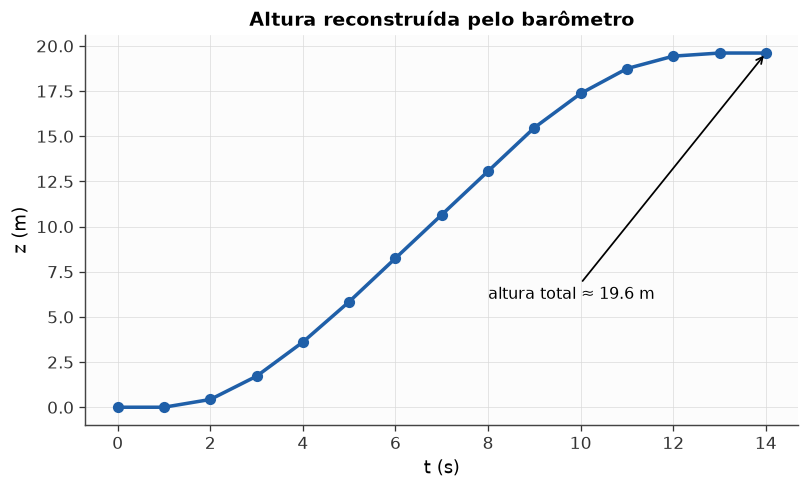

altura total: 19.6 m  (~7 andares)
tempo em movimento: 11 s → velocidade média 1.8 m/s


In [9]:
P_elev = np.array([101.320, 101.320, 101.315, 101.300, 101.278, 101.252,
                   101.224, 101.196, 101.168, 101.140, 101.118, 101.102,
                   101.094, 101.092, 101.092])
t = np.arange(len(P_elev))
T_amb = 24 + 273.15
z_rec = a*T_amb*np.log(P_elev[0]/P_elev)   # hipsométrica, referida ao térreo

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(t, z_rec, 'o-', color=CORES['azul'])
ax.set(xlabel='t (s)', ylabel='z (m)', title='Altura reconstruída pelo barômetro')
ax.annotate(f'altura total ≈ {z_rec[-1]:.1f} m', xy=(t[-1], z_rec[-1]),
            xytext=(8, 6), fontsize=10,
            arrowprops=dict(arrowstyle='->', lw=1.1))
plt.show()

subida = np.diff(z_rec) > 0.2
dt_mov = subida.sum()
print(f'altura total: {z_rec[-1]:.1f} m  (~{z_rec[-1]/3:.0f} andares)')
print(f'tempo em movimento: {dt_mov} s → velocidade média {z_rec[-1]/dt_mov:.1f} m/s')

## N4 — Espessura da sondagem: chuva ou neve?

In [10]:
from metpy.units import units
import metpy.calc as mpcalc

P_s  = np.array([1000, 925, 850, 700, 500]) * units.hPa
T_s  = np.array([27.0, 22.0, 17.5, 9.0, -6.5]) * units.degC
Td_s = np.array([22.0, 19.0, 15.0, 5.0, -14.0]) * units.degC

def espessura_1000_500(T_C):
    """Espessura 1000–500 hPa (m) pela hipsométrica camada a camada."""
    r  = mpcalc.mixing_ratio_from_relative_humidity(
            P_s, T_C, mpcalc.relative_humidity_from_dewpoint(T_C, Td_s))
    Tv = mpcalc.virtual_temperature(T_C, r).to('K').magnitude
    dz = 0.0
    for i in range(len(P_s)-1):
        dz += a*0.5*(Tv[i]+Tv[i+1])*np.log((P_s[i]/P_s[i+1]).magnitude)
    return dz

esp_orig = espessura_1000_500(T_s)
esp_fria = espessura_1000_500((T_s.magnitude - 30)*units.degC)
for nome, e in [('sondagem tropical', esp_orig), ('esfriada em 30 K', esp_fria)]:
    regime = 'CHUVA' if e > 5400 else 'NEVE'
    print(f'{nome:20s}: espessura = {e:6.0f} m  →  {regime}')

sondagem tropical   : espessura =   5769 m  →  CHUVA
esfriada em 30 K    : espessura =   5156 m  →  NEVE


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*